> # SECTION -3

<h4>

**Create quantum circuits**

--- 
- Construct basic quantum circuits
- Construct dynamic circuits
- Construct parameterized circuits
- **Transpile and optimize circuits**
---

</h4>

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ## Transpile and optimize circuits

REFERENCE : 

https://quantum.cloud.ibm.com/docs/en/guides/transpile

https://quantum.cloud.ibm.com/docs/en/guides/defaults-and-configuration-options

https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler

https://quantum.cloud.ibm.com/docs/en/guides/transpiler-stages

<h4>

**TRANSPILE:** 

process of rewriting a given input circuit to match the topology of a specific quantum device, and optimize the circuit instructions for execution on noisy quantum computers
</h4>

---
## Stages of prebuilt transpilation pipeline in the Qiskit SDK. 

---The standard Qiskit pipeline has up to six stages:
```

1. INIT
     ↓
2. LAYOUT
     ↓
3. ROUTING
     ↓
4. TRANSLATION
     ↓
5. OPTIMIZATION
     ↓
6. SCHEDULING

```

> # 1. **init**
<h4>

    - Validates the circuit and unrolls custom or complex multi-qubit instructions into simpler single- and two-qubit gates

    - First stage operates on the abstract/logical circuit.

Its responsibilities include:

    - high-level circuit optimization,
    - simplifying operations,
    - reducing multi-qubit operations,
    - lowering operations involving 3+ qubits into one- and two-qubit operations.

</h4>

> # 2. **layout**
<h4>

    - Maps your abstract "virtual" qubits to the actual physical qubits on the hardware. 
    
    - Choosing an optimal layout is critical for minimizing noise impacts

    In general, quantum circuits are abstract entities whose qubits are "virtual" or "logical" representations of actual qubits used in computations. 
    
    To execute a sequence of gates, a one-to-one mapping from the "virtual" qubits to the "physical" qubits in an actual quantum device is necessary.

    **Example:**

    - Logical circuit:

q0
q1
q2
q3

    - Physical:

Q0 ── Q1 ── Q2 ── Q3 ── Q4

The transpiler needs to determine something like:

    - q0 → Q2
    - q1 → Q1
    - q2 → Q3
    - q3 → Q4

This mapping is called the layout

    - Layout determines which physical hardware qubits correspond to the logical qubits in your circuit.

NOTE:

Choice of mapping is extremely important 
    
- minimize the number of SWAP operations needed to map the input circuit onto the device topology 
        
- ensure to use  most well-calibrated qubits 

To find the best layout
2 steps: 
1.  **"perfect"** :

    - no  SWAP operations required 

    - 2 passes: TrivialLayout,VF2Layout

    - TrivialLayout only used in optimzation_level=1 


2. **"heuristic "** :

    - find the best layout to use if a perfect layout cannot be found

    - 2 passes: DenseLayout,SabreLayout


</h4>

>  # 3. **routing**
<h4>

    Inserts SWAP gates into the circuit so that multi-qubit operations match the physical connectivity (coupling map) of the device

    
Consider hardware:

    Q0 ─── Q1 ─── Q2

but the circuit requires:

    q0 ─────●
            │
    q2 ─────X

If:

    q0 → Q0
    q2 → Q2

then Q0 and Q2 cannot directly interact

**NOTE:**

- Routing inserts additional operations, commonly SWAP operations, to make the required interactions possible.

- Routing can substantially increase circuit depth and the number of two-qubit gates.
- That is important because two-qubit gates are often among the most error-prone operations on quantum hardware.
- SWAP gates are costly and susceptible to noise
- Need to minimize the number of SWAP operations 
- In order to map a quantum circuit onto a given hardware architecture is a crucial objective of the transpilation process.

- Qiskit's routing stage ensures that the resulting circuit respects the connectivity described by the target.

The Layout stage selects the hardware qubits to be used, 

Routing stage inserts the appropriate amount of SWAP gates in order to execute the circuits using the selected layout.

>To find optimal SWAP mapping : Qiskit uses stochastic heuristic algorithm called **SabreSwap**

</h4>

>  # 4. **translation**
    - Convert all gates in the circuit to ones matching the ISA of the Target. 

    - Translates the gates in the circuit to the QPU's basis set of instructions (the basis gates, such as CX, ID, RZ, SX, X)

    - In other words, translates gates specified in a circuit to the native basis gates of a specified backend. 
    
    - This is an important step, as it allows the circuit to be executed by the backend, but typically leads to an increase in the depth and number of gates.




> # 5. **optimization**
<h4>
    - decomposing quantum circuits into the basis gate set of the target device,

    - Runs an iterative loop to reduce overall circuit depth and gate count. 
    
    - It cancels out adjacent inverse gates and compresses sequential single-qubit rotations to lower error rates
    
* **Optimization Level 1:** 

    - Applies `Optimize1qGatesDecomposition` :  to optimize sequences of single-qubit gates 

    - Applies `CXCancellation` : to cancel pairs of consecutive CNOT gates

* **Optimization Level 2:** 

    - Uses `Optimize1qGatesDecomposition` together with `CommutativeCancellation`. 

- Unlike `CXCancellation`, `CommutativeCancellation` identifies and eliminates redundant gates that can be cancelled after accounting for commutation relations between operations.

* **Optimization Level 3:** Performs more aggressive two-qubit and single-qubit optimization. 

It uses:

  * `Collect2qBlocks` to identify and collect consecutive two-qubit gate blocks.

  * `ConsolidateBlocks` to combine each collected block into a single unitary operation.

  * `UnitarySynthesis` to decompose the resulting unitary into an efficient sequence of gates supported by the target basis.

  * `Optimize1qGatesDecomposition` to optimize single-qubit gate sequences.
  
  * `CommutativeCancellation` to remove further redundant gates by exploiting commutation relations.

</h4>

> #  6.**scheduling**

  <h4>

      - Insert Delay instructions to make the wall-clock timing of a circuit explicit.

      - A hardware-aware stage that accounts for qubit idle times, factoring in coherence time limits and minimizing crosstalk distortions

- The scheduling pass explicitly inserts delay instructions to represent idle periods between gate operations.

- It also helps determine the total execution time of the circuit on the target backend.

PARAMETERs:

**asap** :as_soon_as_possible

Schedules each instruction as early as possible, subject to the availability of the required qubit resources

**alap** : 'as_late_as_possible', deafult strategy

Schedules each instruction as late as possible while preserving the circuit's dependencies. This can help keep qubits in their ground state for longer



</h4>

---
> #### BEFORE transpilation

---

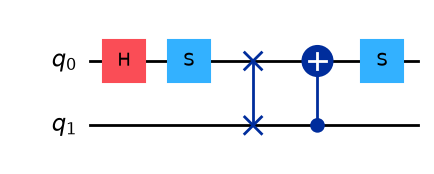

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.h(0)
qc.s(0)
qc.swap(0,1)
qc.cx(1,0)
qc.s(0)

qc.draw("mpl")

---
> #### AFTER transpilation : using decompose

---

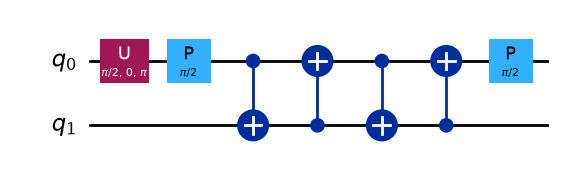

In [3]:
qc.decompose().draw("mpl")

> # Translation example

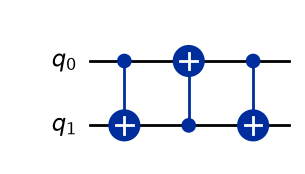

In [4]:
qc = QuantumCircuit(2)
qc.swap(0, 1)
qc.decompose().draw("mpl")

<h4>

### swap gate : 

- not a native gate to the target backend

- requires 3 CNOT gates during trnaslation

</h4>

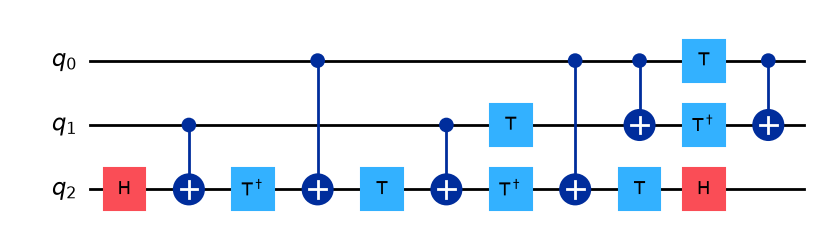

In [5]:
qc = QuantumCircuit(3)
qc.ccx(0, 1, 2)
qc.decompose().draw("mpl")

<h4>

**Toffoli :**

- a three-qubit gate
- Given that our basis gate set includes only single- and two-qubit gates, this operation must be decomposed
- Each Toffoli gate may require up to six CNOT gates along with several single-qubit gates on the hardware.
- Costly decomposition
- Multiple toffoli gates used  will lead to large depth 

</h4>
 

> # Use a fakebackend with 5 qubits : FakeVigoV2 with 5 qubits

In [6]:
from qiskit_ibm_runtime.fake_provider import FakeVigoV2

backend = FakeVigoV2()

print("Number of qubits:", backend.num_qubits)


Number of qubits: 5


> ## Plot gate map for a given backend

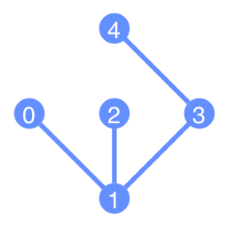

In [7]:
from qiskit.visualization import plot_gate_map
plot_gate_map(backend)

> ## Native gates for given backend

In [8]:
print("native gates:" + str(sorted(backend.operation_names)))

native gates:['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']


> ## Lets use generate_preset_pass_manager for the given backend and view the translation process

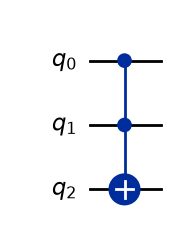

In [9]:
qc.draw("mpl")

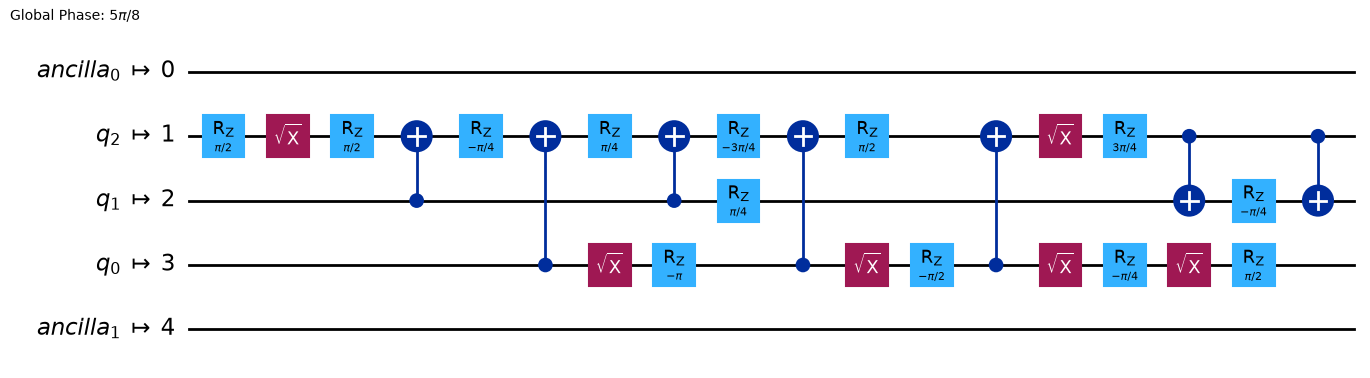

In [10]:
from qiskit.transpiler import generate_preset_pass_manager

# Specify the QPU to target
backend = FakeVigoV2()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=True)

> ## plot the transpiled circuit layout for the given backend 

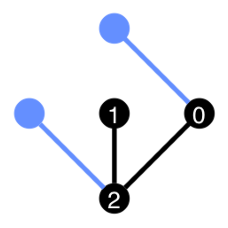

In [11]:
from qiskit.visualization import plot_circuit_layout

plot_circuit_layout(
    transpiled_circ, backend
)

---
> ## Optimize circuits

---

REFERENCE : https://quantum.cloud.ibm.com/docs/en/guides/set-optimization

<h4>

Integer in the range (0 - 3). 

Higher levels generate more optimized circuits, at the expense of longer transpilation time

- 0 : no optimization
- 1 : Light optimization
- 2 : Medium optimization
- 3 : High Optimization

</h4>

---
**using optimization level to 1:**

---

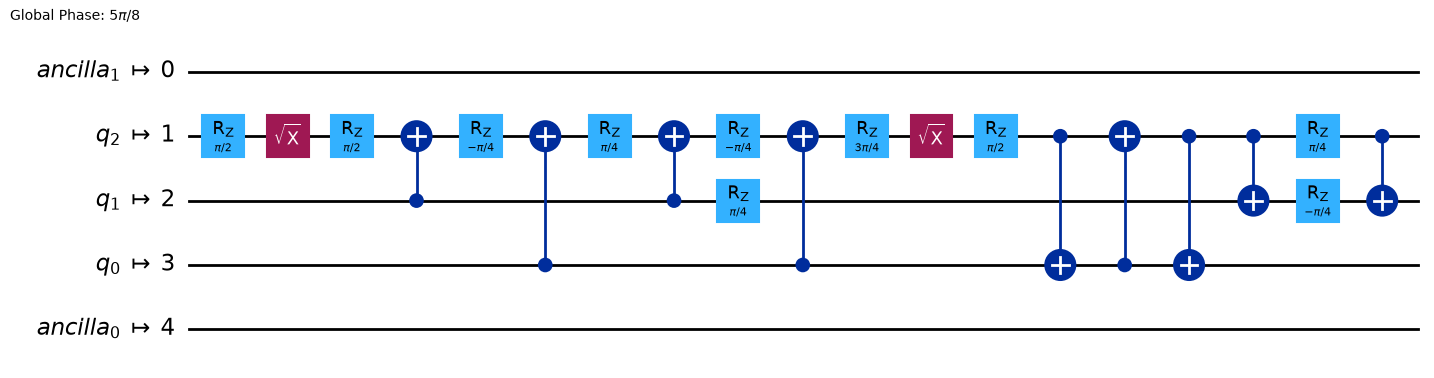

In [12]:
# optimization_level=1


from qiskit.transpiler import generate_preset_pass_manager

# Specify the QPU to target
backend = FakeVigoV2()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=1)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=True)

In [13]:
print("For optimization level = 1")

print("Depth :",transpiled_circ.depth())

print("Gate counts: ",transpiled_circ.count_ops().values())

print("Number of cx gates:",transpiled_circ.count_ops()["cx"])

For optimization level = 1
Depth : 19
Gate counts:  odict_values([10, 9, 2])
Number of cx gates: 9


---
**using optimization level to 2:**

---

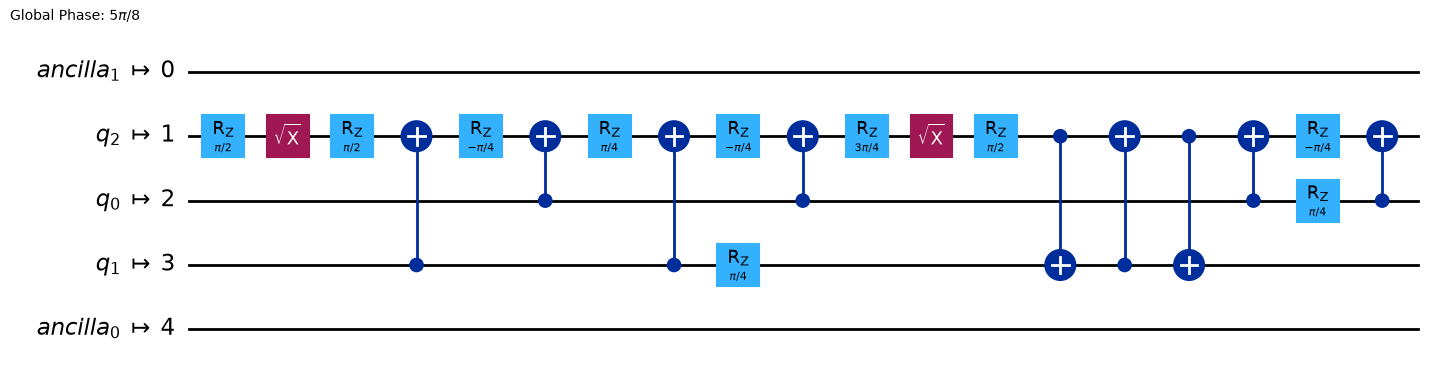

In [14]:

from qiskit.transpiler import generate_preset_pass_manager

# Specify the QPU to target
backend = FakeVigoV2()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=2)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=True)

In [15]:
print("For optimization level = 2")

print("Depth :",transpiled_circ.depth())

print("Gate counts: ",transpiled_circ.count_ops().values())

print("Number of cx gates:",transpiled_circ.count_ops()["cx"])

For optimization level = 2
Depth : 19
Gate counts:  odict_values([10, 9, 2])
Number of cx gates: 9


---
**using optimization level to 3:**

---

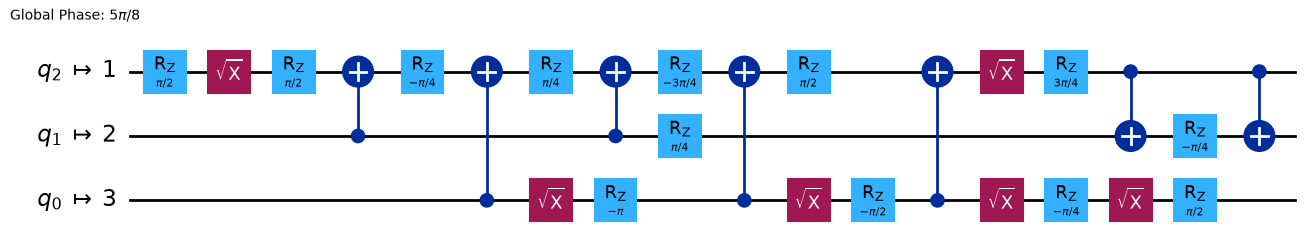

In [16]:
from qiskit.transpiler import generate_preset_pass_manager

# Specify the QPU to target
backend = FakeVigoV2()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=3)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=False)

In [17]:
print("For optimization level = 3")

print("Depth :",transpiled_circ.depth())

print("Gate counts: ",transpiled_circ.count_ops().values())

print("Number of cx gates:",transpiled_circ.count_ops()["cx"])

For optimization level = 3
Depth : 18
Gate counts:  odict_values([13, 7, 6])
Number of cx gates: 7


> # Coupling map

### View the coupling map , edges information for the  given backend

In [18]:
print("Coupling map:", backend.coupling_map.get_edges())

Coupling map: EdgeList[(0, 1), (1, 0), (1, 2), (1, 3), (2, 1), (3, 1), (3, 4), (4, 3)]


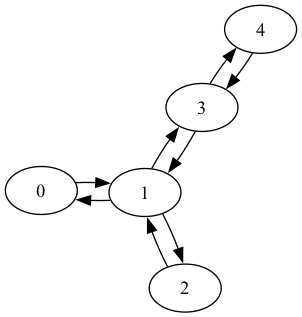

In [19]:
backend.coupling_map.draw()

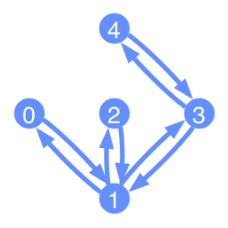

In [20]:
plot_gate_map(
    backend,
    plot_directed=True,
  
)

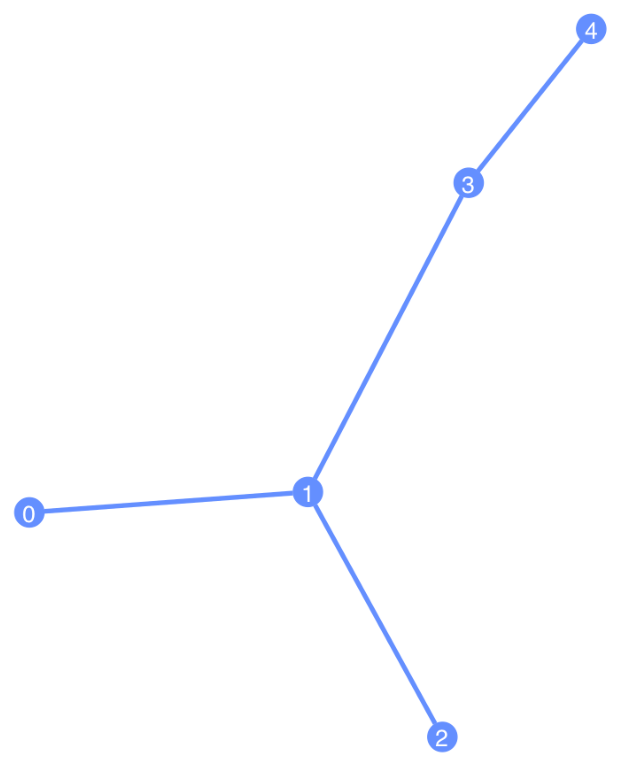

In [21]:

from qiskit.visualization import plot_coupling_map

coupling_map=backend.coupling_map

plot_coupling_map(num_qubits=5, qubit_coordinates=None, coupling_map=coupling_map.get_edges())

> ### Create a quantum circuit : cx is connected from q0 to q1

[[0, 1], [1, 2]]


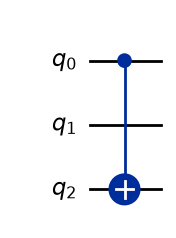

In [22]:
from qiskit import QuantumCircuit, transpile

from qiskit.transpiler import CouplingMap
qc = QuantumCircuit(3)

qc.cx(0, 2)

coupling_map = CouplingMap([[0, 1], [1, 2]])

print(coupling_map)

qc.draw("mpl")

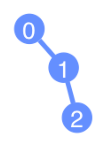

In [23]:
plot_coupling_map(num_qubits=3, qubit_coordinates=None, coupling_map=coupling_map.get_edges())

This means:

Qubit 0 is connected to qubit 1

Qubit 1 is connected to qubit 2

A direct 0 ↔ 2 connection does not exist


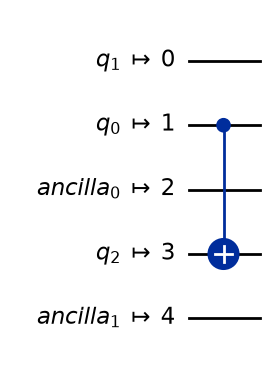

In [24]:
coupling_map = backend.coupling_map

transpiled_qc = transpile(qc,coupling_map=coupling_map , optimization_level=2)

transpiled_qc.draw("mpl",idle_wires=True)

Plot the layout of a circuit transpiled for a given target backend.



"virtual": Label each qubit with the index of the virtual qubit that mapped to it.
"physical": Label each qubit with the index of the physical qubit that it corresponds to on the device.

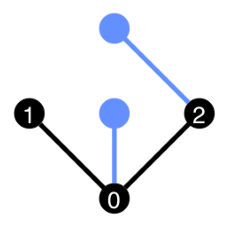

In [25]:
from qiskit.visualization import plot_circuit_layout

plot_circuit_layout(transpiled_qc, backend)